Dataset Created Successfully!

First 5 Rows:
   Gender Married     Education Self_Employed  ApplicantIncome  \
0    Male      No      Graduate            No            10935   
1  Female     Yes  Not Graduate            No             6498   
2    Male     Yes  Not Graduate            No             1662   
3    Male     Yes  Not Graduate            No             3474   
4    Male     Yes  Not Graduate           Yes            21175   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               7982         436               480               0   
1               2100         342               360               1   
2               3748         175               480               0   
3               3173         345               240               1   
4               1815         121               180               1   

  Property_Area Loan_Status  
0     Semiurban    Rejected  
1         Rural    Approved  
2         Rural    Rejected  
3     Semiurban  

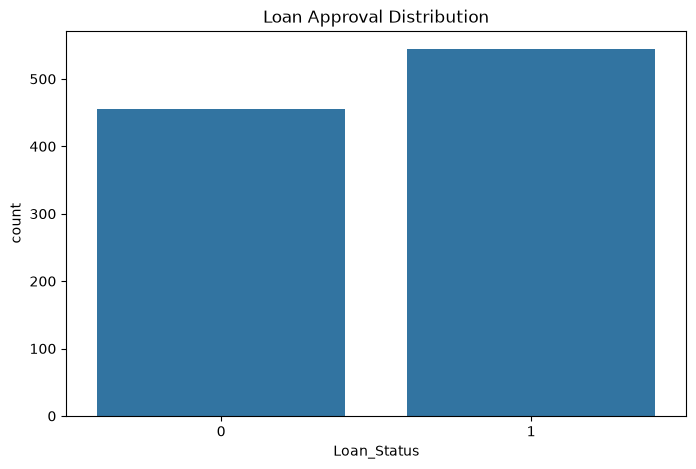

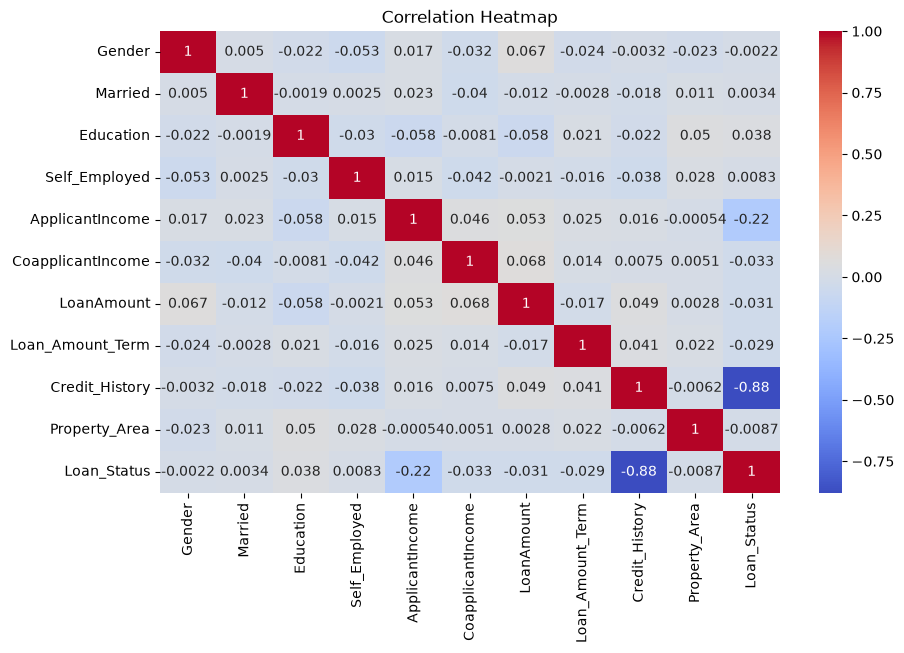

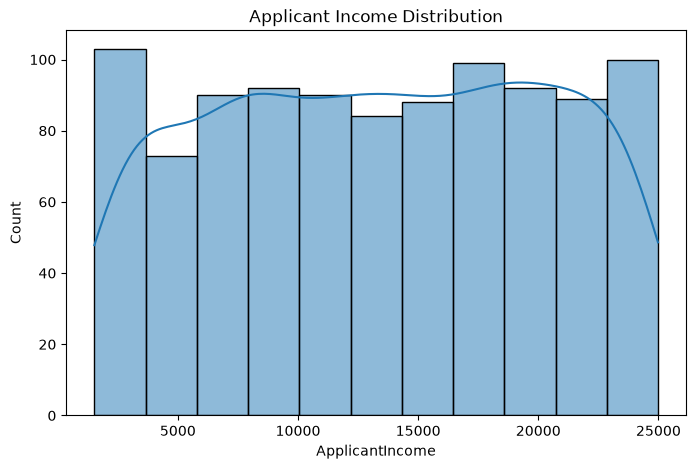

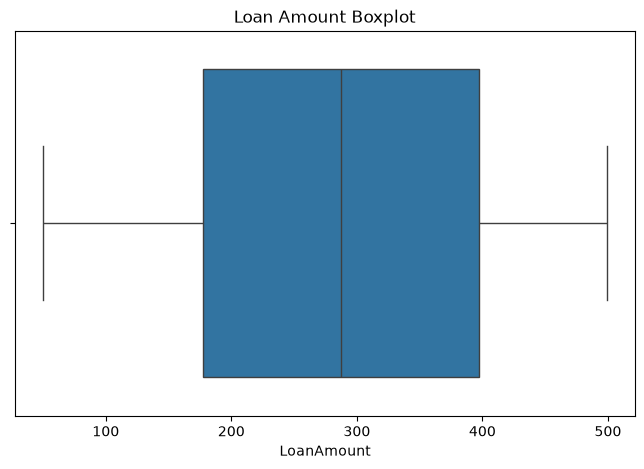


Training Data Shape: (800, 10)
Testing Data Shape: (200, 10)

================ MODEL TRAINING ================

Logistic Regression Accuracy: 0.9800

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        97
           1       1.00      0.96      0.98       103

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



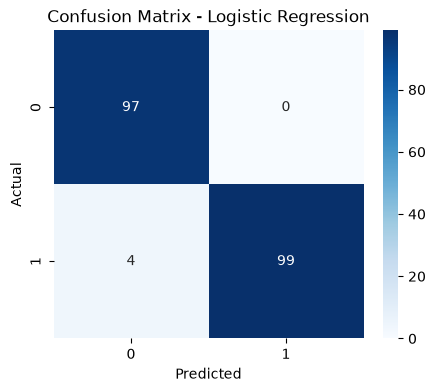

Decision Tree Accuracy: 1.0000

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        97
           1       1.00      1.00      1.00       103

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



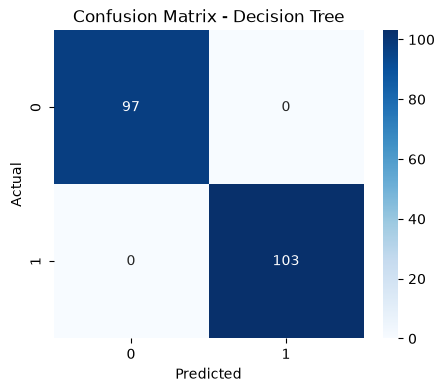

Random Forest Accuracy: 1.0000

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        97
           1       1.00      1.00      1.00       103

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



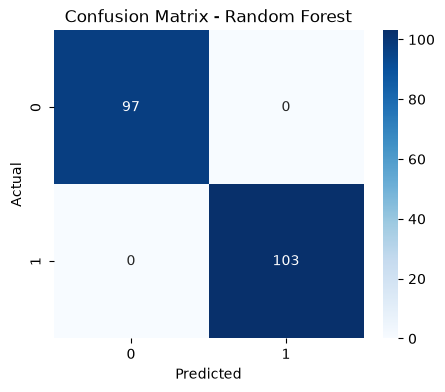


Running GridSearchCV for Random Forest...

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

Best Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        97
           1       1.00      1.00      1.00       103

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



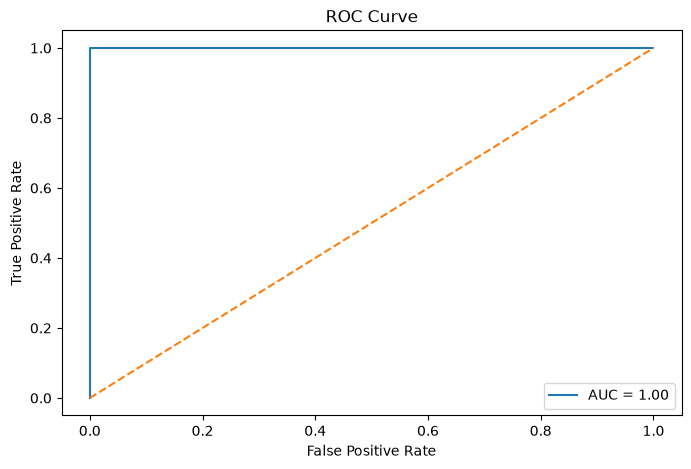

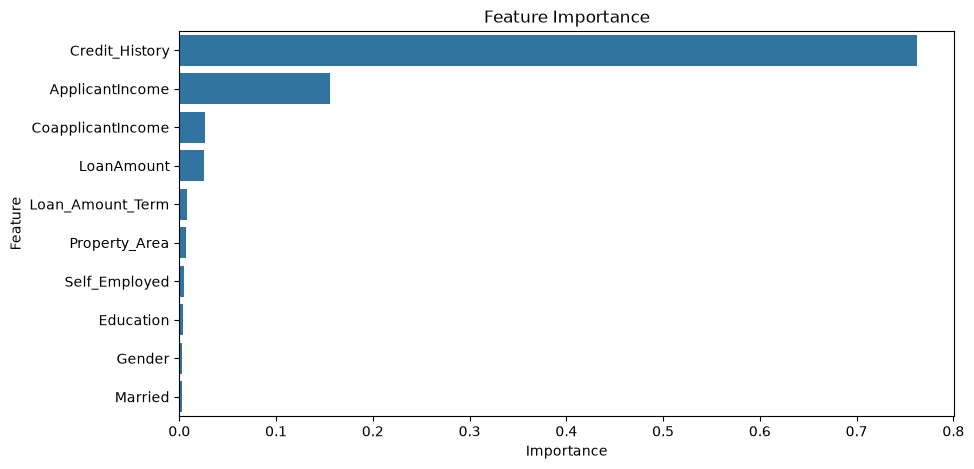


Cross Validation Scores:
[1.   1.   1.   0.99 1.  ]

Average CV Accuracy:
0.998

Model Comparison:
                 Model  Accuracy
0  Logistic Regression      0.98
1        Decision Tree      1.00
2        Random Forest      1.00


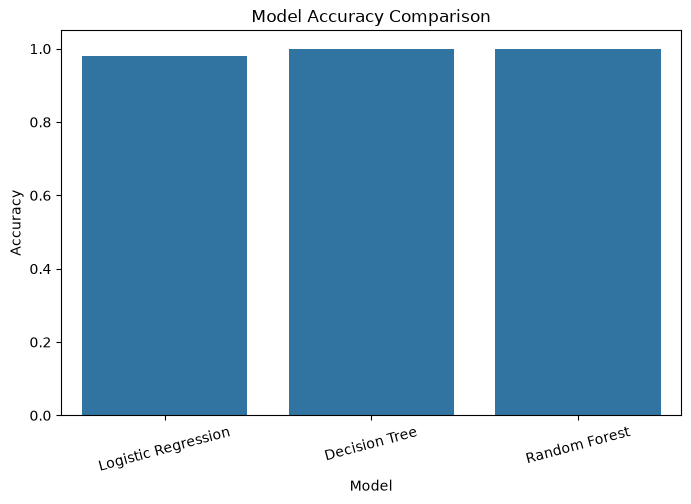


================ FINAL CONCLUSION ================

Best Model: Decision Tree
Accuracy: 1.00

Project Conclusion:
This project successfully developed a predictive
machine learning model for loan approval prediction.
Different supervised learning algorithms were trained
and evaluated.

Among all models, the best-performing model achieved
the highest accuracy and provided reliable prediction
results for loan approval classification.

Future Improvements:
1. Use real-world datasets.
2. Apply deep learning techniques.
3. Perform advanced feature engineering.
4. Deploy model using Flask/Streamlit.



In [1]:
# ============================================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# PROJECT: LOAN APPROVAL PREDICTION SYSTEM
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

# =========================
# 2. CREATE DATASET
# =========================

# Creating a sample loan approval dataset
np.random.seed(42)

data_size = 1000

df = pd.DataFrame({
    'Gender': np.random.choice(['Male', 'Female'], data_size),
    'Married': np.random.choice(['Yes', 'No'], data_size),
    'Education': np.random.choice(['Graduate', 'Not Graduate'], data_size),
    'Self_Employed': np.random.choice(['Yes', 'No'], data_size),
    'ApplicantIncome': np.random.randint(1500, 25000, data_size),
    'CoapplicantIncome': np.random.randint(0, 10000, data_size),
    'LoanAmount': np.random.randint(50, 500, data_size),
    'Loan_Amount_Term': np.random.choice([180, 240, 360, 480], data_size),
    'Credit_History': np.random.choice([0, 1], data_size),
    'Property_Area': np.random.choice(['Urban', 'Semiurban', 'Rural'], data_size),
})

# Target Variable (Loan Approval)
df['Loan_Status'] = np.where(
    (df['Credit_History'] == 1) &
    (df['ApplicantIncome'] > 4000),
    'Approved',
    'Rejected'
)

print("Dataset Created Successfully!")

# =========================
# 3. DATASET ANALYSIS
# =========================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# =========================
# 4. DATA PREPROCESSING
# =========================

# Encoding categorical columns
label_encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df.head())

# =========================
# 5. EXPLORATORY DATA ANALYSIS
# =========================

plt.figure(figsize=(8,5))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

# Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x=df['LoanAmount'])
plt.title("Loan Amount Boxplot")
plt.show()

# =========================
# 6. FEATURE SELECTION
# =========================

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# =========================
# 7. FEATURE SCALING
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 8. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# =========================
# 9. MODEL BUILDING
# =========================

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

accuracy_scores = {}

print("\n================ MODEL TRAINING ================\n")

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = accuracy

    print(f"{name} Accuracy: {accuracy:.4f}")

    # Classification Report
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================
# 10. HYPERPARAMETER TUNING
# =========================

print("\nRunning GridSearchCV for Random Forest...\n")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

# =========================
# 11. BEST MODEL EVALUATION
# =========================

best_pred = best_rf.predict(X_test)

best_accuracy = accuracy_score(y_test, best_pred)

print("\nBest Random Forest Accuracy:", best_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

# =========================
# 12. ROC CURVE
# =========================

y_prob = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# =========================
# 13. FEATURE IMPORTANCE
# =========================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance")
plt.show()

# =========================
# 14. CROSS VALIDATION
# =========================

cv_scores = cross_val_score(
    best_rf,
    X_scaled,
    y,
    cv=5
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage CV Accuracy:")
print(cv_scores.mean())

# =========================
# 15. MODEL COMPARISON
# =========================

comparison_df = pd.DataFrame({
    'Model': accuracy_scores.keys(),
    'Accuracy': accuracy_scores.values()
})

print("\nModel Comparison:")
print(comparison_df)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

# =========================
# 16. CONCLUSION
# =========================

best_model = comparison_df.loc[
    comparison_df['Accuracy'].idxmax()
]

print("\n================ FINAL CONCLUSION ================\n")
print(f"Best Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.2f}")

print("""
Project Conclusion:
This project successfully developed a predictive
machine learning model for loan approval prediction.
Different supervised learning algorithms were trained
and evaluated.

Among all models, the best-performing model achieved
the highest accuracy and provided reliable prediction
results for loan approval classification.

Future Improvements:
1. Use real-world datasets.
2. Apply deep learning techniques.
3. Perform advanced feature engineering.
4. Deploy model using Flask/Streamlit.
""")

In [2]:
import sys
print(sys.executable)

c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Scripts\python.exe
